In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn import preprocessing

In [2]:
import opendatasets as od

dataset_url = "https://www.kaggle.com/datasets/mirichoi0218/insurance"
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  Hennessyss


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance


100%|██████████| 16.0k/16.0k [00:00<00:00, 8.30MB/s]

In [3]:
# Carga de datos.
df = pd.read_csv("insurance/insurance.csv")
print(df)


      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [4]:
# Eliminamos el atributo
# (axis=1 indica que vas a eliminar una columna y inplace=True aplica el cambio directamente en tu df)
df.drop(columns=['region'], inplace=True)

# Verificamos que ya no aparezca
df.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [5]:
# Mapear los valores de la columna
df['sex'] = df['sex'].map({'female': 1, 'male': 0})

# Verificar el cambio
df.head()

,age,sex,bmi,children,smoker,charges
0,19,1,27.900,0,yes,16884.92400
1,18,0,33.770,1,no,1725.55230
2,28,0,33.000,3,no,4449.46200
3,33,0,22.705,0,no,21984.47061
4,32,0,28.880,0,no,3866.85520


In [6]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# Verificar el cambio
df.head()

,age,sex,bmi,children,smoker,charges
0,19,1,27.900,0,1,16884.92400
1,18,0,33.770,1,0,1725.55230
2,28,0,33.000,3,0,4449.46200
3,33,0,22.705,0,0,21984.47061
4,32,0,28.880,0,0,3866.85520


In [22]:
#Calidad de los datos
print("Información general del dataset:")
print(df.info())

print("\nConteo de valores nulos por columna:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 62.8 KB
None

Conteo de valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

Estadísticas descriptivas:


,age,sex,bmi,children,smoker,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.494768,30.663397,1.094918,0.204783,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,4740.287150
50%,39.000000,0.000000,30.400000,1.000000,0.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


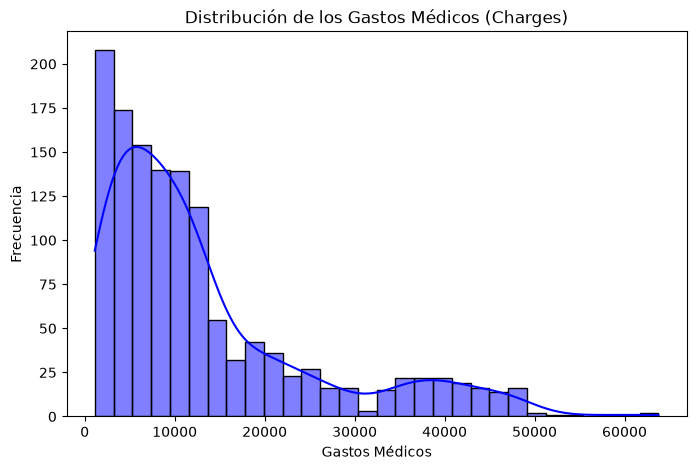

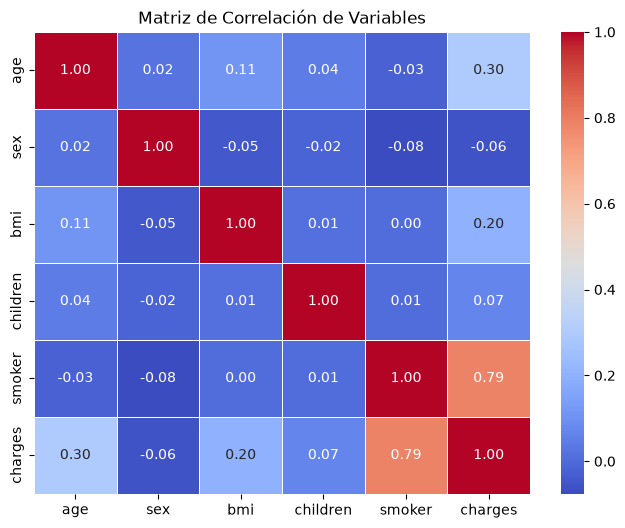

In [24]:
# Distribución de la variable objetivo 'charges'
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True, color='blue', bins=30)
plt.title('Distribución de los Gastos Médicos (Charges)')
plt.xlabel('Gastos Médicos')
plt.ylabel('Frecuencia')
plt.show()

# Matriz de correlación
# Las variables influyen más en charges
plt.figure(figsize=(8, 6))
matriz_corr = df.corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

In [25]:
# Detección de valores atípicos (Outliers) usando el método del Rango Intercuartílico (IQR)
for col in ['age', 'bmi']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificar filas fuera de los límites
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"Outliers detectados en {col}: {len(outliers)}")

Outliers detectados en age: 0
Outliers detectados en bmi: 9


Posición de outliers:  [ 116  286  401  543  847  860 1047 1088 1317]
Número de outliers:  9


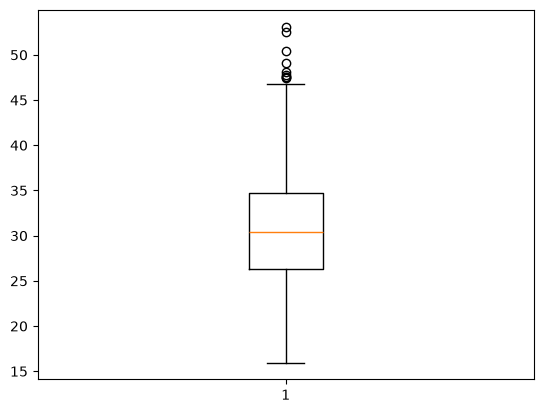

In [26]:
# Buscamos la posición de los outliers
pos_i = np.where(df[col] < limite_inferior)[0]
pos_s = np.where(df[col] > limite_superior)[0]
pos_outliers = np.concatenate((pos_i, pos_s))
print('Posición de outliers: ', pos_outliers)
print('Número de outliers: ', len(pos_outliers))

# Dibujamos el diagrama de caja y bigotes
prop = plt.boxplot(df[col])
plt.show()

In [27]:
# Separar características (X) y variable objetivo (y)
X = df.drop(columns=['charges'])
y = df['charges']

In [28]:
# Validación: División en entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Creamos el objeto estandarizador
scaler = StandardScaler()

# Estandarizamos los datos de entrenamiento (fit y transform)
X_train_scaled = scaler.fit_transform(X_train)

# Estandarizamos los datos de prueba (SOLO transform)
X_test_scaled = scaler.transform(X_test)

print("Datos de entrenamiento estandarizados (primeras 3 filas):")
print(X_train_scaled[:3])

Datos de entrenamiento estandarizados (primeras 3 filas):
[[ 0.47222651  1.0246016  -1.75652513  0.73433626 -0.50874702]
 [ 0.54331294  1.0246016  -1.03308239 -0.91119211 -0.50874702]
 [ 0.8987451   1.0246016  -0.94368672 -0.91119211 -0.50874702]]


In [34]:
# Creamos el selector para elegir las 4 mejores características usando f_regression
selector = SelectKBest(score_func=f_regression, k=4)

# Ajustamos y transformamos los datos de entrenamiento
X_train_selected = selector.fit_transform(X_train_scaled, y_train)

# Transformamos los datos de prueba (solo transform)
X_test_selected = selector.transform(X_test_scaled)

# Mostrar qué atributos fueron seleccionados
columnas_seleccionadas = X.columns[selector.get_support()]
print("Características seleccionadas para el modelo:", list(columnas_seleccionadas))

# Mostrar los puntajes (scores) de todas las características para justificar la selección
puntajes = pd.DataFrame({'Atributo': X.columns, 'Puntaje F-test': selector.scores_})
print("\nImportancia de cada atributo:")
display(puntajes.sort_values(by='Puntaje F-test', ascending=False))

Características seleccionadas para el modelo: ['age', 'bmi', 'children', 'smoker']

Importancia de cada atributo:


,Atributo,Puntaje F-test
4,smoker,1659.952101
0,age,92.070905
2,bmi,43.265710
3,children,5.547503
1,sex,3.457075


In [36]:
# ENTRENAMIENTO 
modelo = LinearRegression()
# Entrenamos con los datos estandarizados y seleccionados
modelo.fit(X_train_selected, y_train)

print("RESULTADOS DEL ENTRENAMIENTO")
print("Interceptor (Beta 0):", modelo.intercept_)
print("\nCoeficientes para cada variable seleccionada:")
for col, coef in zip(columnas_seleccionadas, modelo.coef_):
    print(f"{col}: {coef:.2f}")

# EVALUACIÓN
# Hacemos predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test_selected)

# Calculamos las métricas de error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMÉTRICAS DE EVALUACIÓN")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")

RESULTADOS DEL ENTRENAMIENTO
Interceptor (Beta 0): 13346.089736364485

Coeficientes para cada variable seleccionada:
age: 3616.32
bmi: 1978.42
children: 519.23
smoker: 9559.32

MÉTRICAS DE EVALUACIÓN
Error Cuadrático Medio (MSE): 33981653.95
Raíz del Error Cuadrático Medio (RMSE): 5829.38
Coeficiente de Determinación (R2): 0.7811


In [42]:
# PREDICCIÓN CON NUEVOS DATOS
print("ESTIMADOR DE GASTOS MÉDICOS")
edad_ingresada = float(input("Ingrese la edad: "))

# Validación para sexo
sexo_ingresado = -1
while sexo_ingresado not in [0, 1]:
    sexo_ingresado = int(input("Ingrese sexo (1 para mujer, 0 para hombre): "))

imc_ingresado = float(input("Ingrese el IMC: "))

# Validación para niños
ninos_ingresado = -1
while ninos_ingresado < 0:
    ninos_ingresado = int(input("Ingrese número de niños: "))

# Validación para fumador
fumador_ingresado = -1
while fumador_ingresado not in [0, 1]:
    fumador_ingresado = int(input("¿Fuma? (1 para sí, 0 para no): "))
# Crear el DataFrame temporal
nuevo_caso = pd.DataFrame([{
    'age': edad_ingresada, 
    'sex': sexo_ingresado, 
    'bmi': imc_ingresado, 
    'children': ninos_ingresado, 
    'smoker': fumador_ingresado
}])

# Escalar los datos usando el scaler (solo transform)
nuevo_caso_scaled = scaler.transform(nuevo_caso)

# Filtrar para quedarse solo con los mejores atributos usando el selector (solo transform)
nuevo_caso_selected = selector.transform(nuevo_caso_scaled)

# Realizar la predicción
prediccion_costo = modelo.predict(nuevo_caso_selected)
print(f"\nGastos médicos estimados: USD {prediccion_costo[0]:.2f}")

ESTIMADOR DE GASTOS MÉDICOS


Ingrese la edad:  18
Ingrese sexo (1 para mujer, 0 para hombre):  1
Ingrese el IMC:  25
Ingrese número de niños:  0
¿Fuma? (1 para sí, 0 para no):  1



Gastos médicos estimados: USD 24351.48


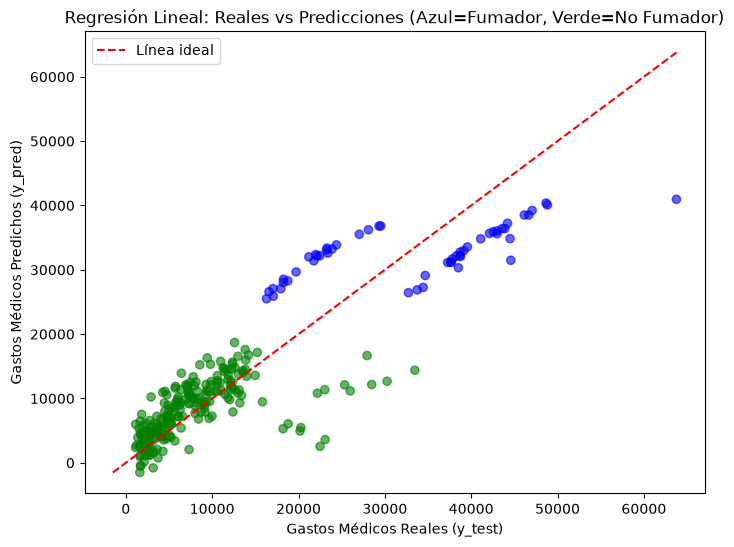

In [47]:
plt.figure(figsize=(8,6))

# Crea un arreglo de colores: azul para fumadores, verde para no fumadores
colores_condicionales = np.where(X_test['smoker'] == 1, 'blue', 'green')

# Se usa el parámetro 'c' para pasar la lista de colores múltiples
plt.scatter(y_test, y_pred, c=colores_condicionales, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Línea ideal')

plt.xlabel('Gastos Médicos Reales (y_test)')
plt.ylabel('Gastos Médicos Predichos (y_pred)')
plt.title('Regresión Lineal: Reales vs Predicciones (Azul=Fumador, Verde=No Fumador)')
plt.legend()

plt.show()